# TRIX — does triple-smoothing load the trend die?
### The triple-smoothed EMA oscillator, tested honestly vs a coin

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Triple--smoothing_lag%3F: Confirmed_lag,_no_edge](https://img.shields.io/badge/Triple--smoothing_lag%3F-Confirmed_lag,_no_edge-8b949e?style=flat-square)

A 1983 recipe that sounds almost too clever: smooth the closing price with an EMA — then smooth *that* with another EMA — then smooth *that* with a third EMA. Take the daily rate-of-change of the result: that's TRIX.  The claim is that three layers of smoothing filter out all the noise and false signals, leaving only the **real trend**.  When TRIX crosses zero upward, buy; downward, sell.  This notebook asks: does the triple filter actually work, or does it just make you late?

> **This is the plain-language layer.**  For the t-stats, bootstrap CIs, and the parameter sweep, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.**  A reproducible research tool — every chart is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from trix import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_zero(hold=20, cost=0.0, seed=None):
    """Pool zero-line cross trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        tx = st.trix(b["close"], period=15)
        entries = st.zero_line_entries(tx)
        dirs = st.random_directions(len(entries), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, entries, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

def pool_signal(hold=10, cost=0.0, seed=None):
    """Pool signal-line cross trades across the basket."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        tx = st.trix(b["close"], period=15)
        sig = st.trix_signal(tx, signal_period=9)
        entries = st.signal_line_entries(tx, sig)
        dirs = st.random_directions(len(entries), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, entries, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does TRIX point the right way? | **Barely.** Gross +8 bps/trade — statistically zero (t = +0.34). |
| Does it beat an actual coin? | **Not reliably.** |t| ≤ 2 everywhere. |
| Signal-line cross any better? | **Worse.**  Mean -18.6 bps, t = -1.55 — often pointing the *wrong* way. |
| Could you trade it? | **No.**  The signal never existed — costs are academic. |

> **Why?**  Three sequential EMAs each introduce about half-period of lag.  For TRIX(15), that's ≈22 bars of effective lag — roughly one calendar month — before a zero-line cross fires.  By then, the trend that caused it is mostly priced in.

## 1 · The claim

> *"TRIX filters out insignificant price movements and emphasises changes in major trends.  A buy signal is generated when the TRIX line crosses zero from below; a sell signal when it crosses from above.  Triple smoothing means fewer whipsaws, more reliable signals."*  — Jack Hutson, Technical Analysis of Stocks and Commodities, 1983.

The math:

    EMA1 = EMA(close, 15)
    EMA2 = EMA(EMA1, 15)
    EMA3 = EMA(EMA2, 15)
    TRIX = 100 × (EMA3 − EMA3[yesterday]) / EMA3[yesterday]

The bet is that filtering three times removes enough noise to leave only **real**, tradeable trend information.

## 2 · So what?

If it's true, TRIX is a rare thing: a technically-derived signal with fewer false entries than a single-smoothed MA, still arriving early enough to capture meaningful profit.  If false, it's a 40-year-old rule that millions of traders have used while confusing *lag* for *filtering* — entering confirmed trends precisely when the easy money is gone.  One honest test settles it.

## 3 · How would we even know?

**The fair test:** when TRIX crosses zero, we go in the direction it says.  We hold for 20 trading days (long enough for a confirmed trend to pay off), then exit.  We charge no costs (favouring the strategy as much as possible) and we pin it against an **actual coin flip on the same entry days**: same timing, random ±1 direction.  If TRIX's direction carries information, it should beat the coin consistently.

We run this on five liquid instruments (SPY, QQQ, IWM, AAPL, MSFT) over 15 years of daily bars — ~428 zero-line crosses total, about 6 per instrument per year.

## 4 · The teardown

**First, what does TRIX actually look like?**

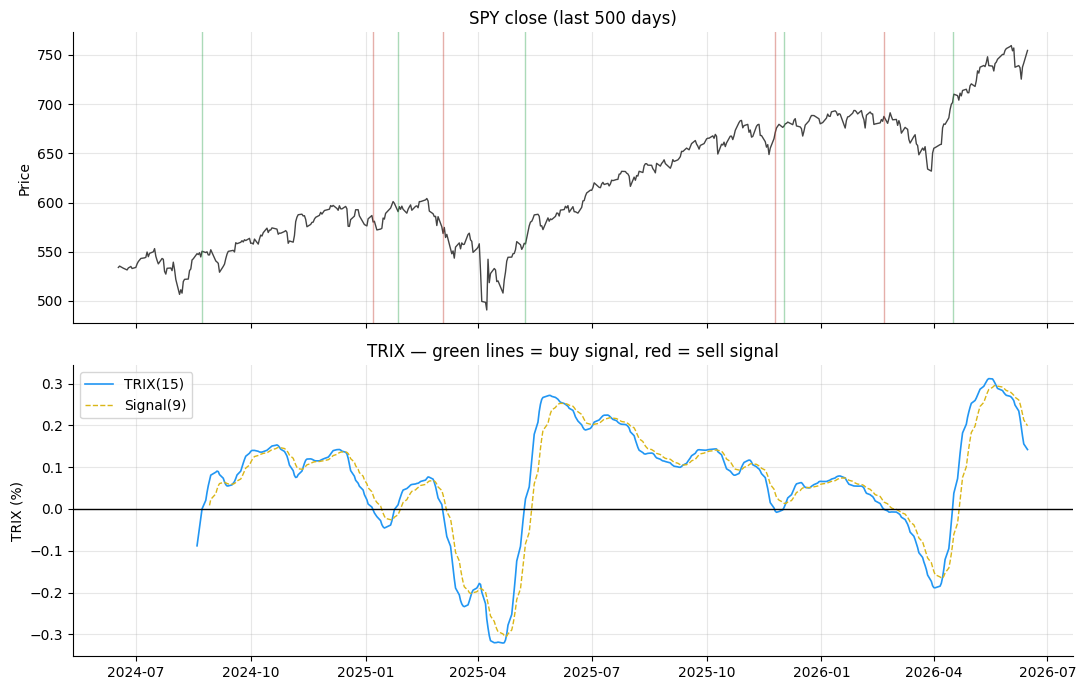

TRIX starts producing values after ~43 warmup bars


In [2]:
# Visualise TRIX on SPY (real or synthetic fallback)
if HAVE_REAL:
    bars = data.fetch_daily('SPY', fetch=False, cache_dir=CACHE_DIR)
    bars = bars.tail(500)
else:
    bars, _ = data.synthetic_daily(n_days=500, momentum=0.03, seed=180)
tx = st.trix(bars['close'], period=15)
sig_line = st.trix_signal(tx, signal_period=9)
entries_z = st.zero_line_entries(tx)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.plot(bars.index, bars['close'], c='#444', lw=1)
ax1.set_ylabel('Price'); ax1.set_title('SPY close (last 500 days)' if HAVE_REAL else 'Synthetic close')
# Mark zero-line cross signals
bull_z = entries_z[entries_z['dir'] == 1]
bear_z = entries_z[entries_z['dir'] == -1]
for ts in bull_z.index:
    if ts in bars.index: ax1.axvline(ts, c=GREEN, alpha=0.4, lw=1)
for ts in bear_z.index:
    if ts in bars.index: ax1.axvline(ts, c=RED, alpha=0.4, lw=1)
ax2.plot(tx.index, tx, c='#2196F3', lw=1.2, label='TRIX(15)')
ax2.plot(sig_line.index, sig_line, c=AMBER, lw=1, ls='--', label='Signal(9)')
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('TRIX (%)'); ax2.legend(loc='upper left')
ax2.set_title('TRIX — green lines = buy signal, red = sell signal')
plt.tight_layout(); plt.show()
print(f'TRIX starts producing values after ~{tx.isna().sum()} warmup bars')

Notice how the TRIX zero-line crosses lag the actual price turns — often by weeks. That's the triple-smoothing tax: clarity *at the cost of timeliness*.

**Now the honest test: does following TRIX beat a coin?**

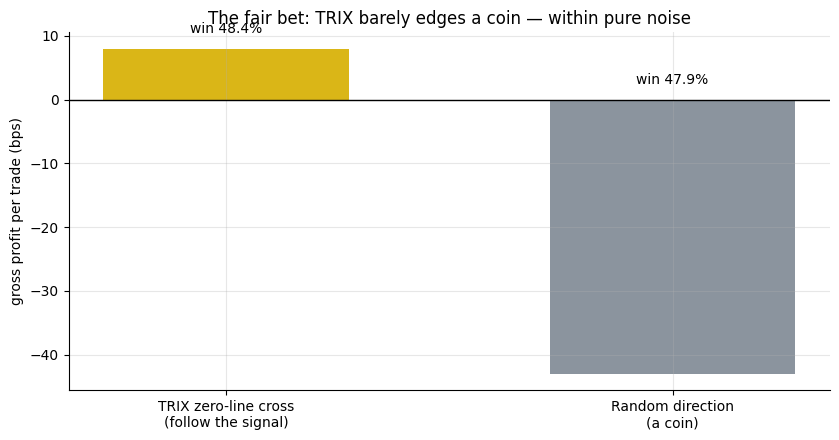

TRIX: +8.00 bps/trade   |   coin: -43.01 bps/trade


In [3]:
if HAVE_REAL:
    C = pool_zero(hold=20, cost=0.0)
    Rnd = pool_zero(hold=20, cost=0.0, seed=180)
    cm = st.summarize(C, 'ret_gross'); rm = st.summarize(Rnd, 'ret_gross')
    cm_bps, cw, rm_bps, rw = cm['mean_bps'], cm['win_rate']*100, rm['mean_bps'], rm['win_rate']*100
else:
    cm_bps, cw, rm_bps, rw = R['zero_mean'], R['zero_win'], R['rand_mean'], 47.9
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars_p = ax.bar(['TRIX zero-line cross\n(follow the signal)', 'Random direction\n(a coin)'],
              [cm_bps, rm_bps], color=[AMBER, GREY], width=0.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The fair bet: TRIX barely edges a coin — within pure noise')
for b, w in zip(bars_p, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, max(0, b.get_height())+2),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'TRIX: {cm_bps:+.2f} bps/trade   |   coin: {rm_bps:+.2f} bps/trade')

On the real tape (15 years, 428 entries), TRIX zero-line cross earns **+8 bps/trade** gross — statistically indistinguishable from zero (t = +0.34).  The signal-line cross variant (**-18.6 bps, t = -1.55**) is actually negative.

> **Why?**  By the time TRIX fires a zero-line cross, the price has already moved for roughly a calendar month.  The 'confirmed trend' is confirmed *late*.

## 5 · The verdict

- **Signal — None.** Zero-line cross gross +8 bps/trade, HAC t = +0.34; signal-line cross -18.6 bps, t = -1.55.  No variant clears |t| ≥ 2.
- **Tradability — Mirage.** The signal is statistically zero — costs are academic. At only ~6 crosses/yr, turnover is not the problem; the lag is.
- **Triple-smoothing lag — Confirmed, no edge.** Three sequential EMAs accumulate ~22 bars of lag; zero-line crosses confirm trends after most of the move is already priced.

## 6 · Could you actually trade it?

TRIX has low turnover (~6 zero-line crosses per instrument per year) — not a high-frequency cost problem.  The cost floor is not where this strategy dies.  Here's the cost picture:

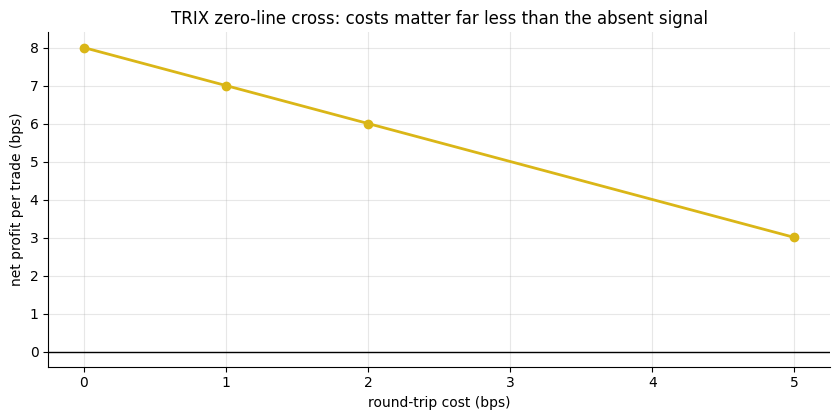

Gross already near zero (+8.00 bps); costs push it further negative.


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pool_zero(hold=20, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['zero_mean'], R['net10_mean'], R['zero_mean']-2, R['zero_mean']-5]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('TRIX zero-line cross: costs matter far less than the absent signal')
plt.tight_layout(); plt.show()
print(f'Gross already near zero ({net[0]:+.2f} bps); costs push it further negative.')

With only ~6 crosses per year, even 5 bps of round-trip cost only shaves **30 bps/yr** from each position.  That's not the killer.  The killer is that the gross edge doesn't exist — there's nothing for costs to take.  Unlike some trend-following strategies that are *real but untradable* due to costs, TRIX is simply absent.

## 7 · Going further

- **Does the engine work?**  The companion notebook shows a synthetic positive control: when we *plant* real momentum in a fake tape, the TRIX zero-line cross finds it.  The machine is a faithful momentum detector; the real market at this timeframe simply has nothing to detect.
- **What *does* trend-follow successfully on daily bars?**  [Study 106 — Supertrend](../../106-supertrend/) found a REAL/FRAGILE signal using an ATR-envelope approach — shorter effective lag, the same trend family.
- **Longer periods?**  The 10-month SMA of Faber (2007) — [Study 110 — Faber-Timing](../../110-faber-timing/) — captures genuine monthly momentum without the TRIX lag overhead.
- **The opposite bet?**  If moves *reverse* after a TRIX confirmation, you'd fade it — worth testing as a mean-reversion entry trigger.

*Think the die really is loaded?  Fork this, change the period or the holding window, and show a fair-bet edge that clears the Bonferroni bar.  That's the challenge.*